<a href="https://colab.research.google.com/github/sulthanalihsan/data-science-2026/blob/main/Pertemuan3_Muhamad_Sulthan_Al_Ihsan_250401020154.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 3: Data Cleaning
**Nama  :** Muhammad Sulthan Al Ihsan

**NIM   :** 250401020154

**Mata Kuliah:** Data Science —  S1 PJJ Informatika

**Kelas:** IF401

In [ ]:
import pandas as pd, numpy as np
import missingno as msno   # pip install missingno
from google.colab import drive
drive.mount('/content/drive')
import requests

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ls "drive/MyDrive/Colab Notebooks/kuliah - unsia - data science/pertemuan 3/housing_dirty.csv"

'drive/MyDrive/Colab Notebooks/kuliah - unsia - data science/pertemuan 3/housing_dirty.csv'


id               0
luas_m2         18
harga_juta      17
kota             0
kamar           10
tahun_bangun     0
kondisi          0
dtype: int64
luas_m2       13.85
harga_juta    13.08
kamar          7.69
dtype: float64


<Axes: >

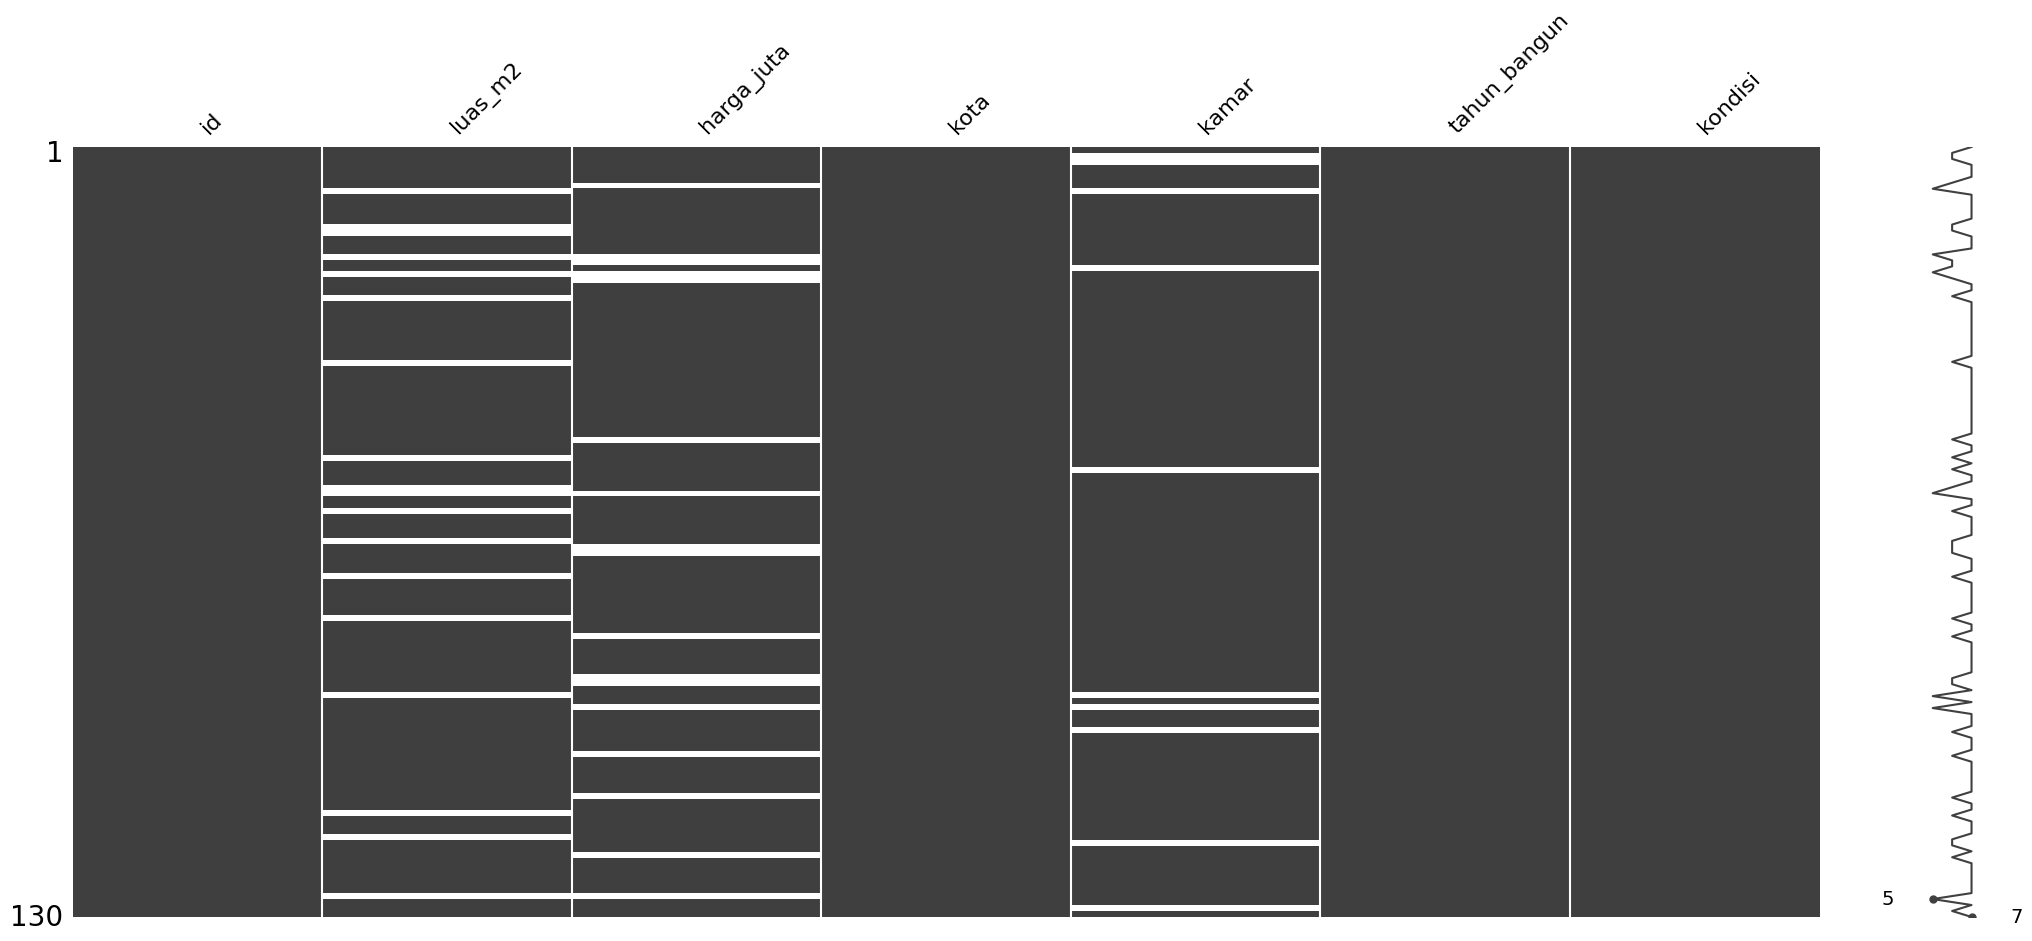

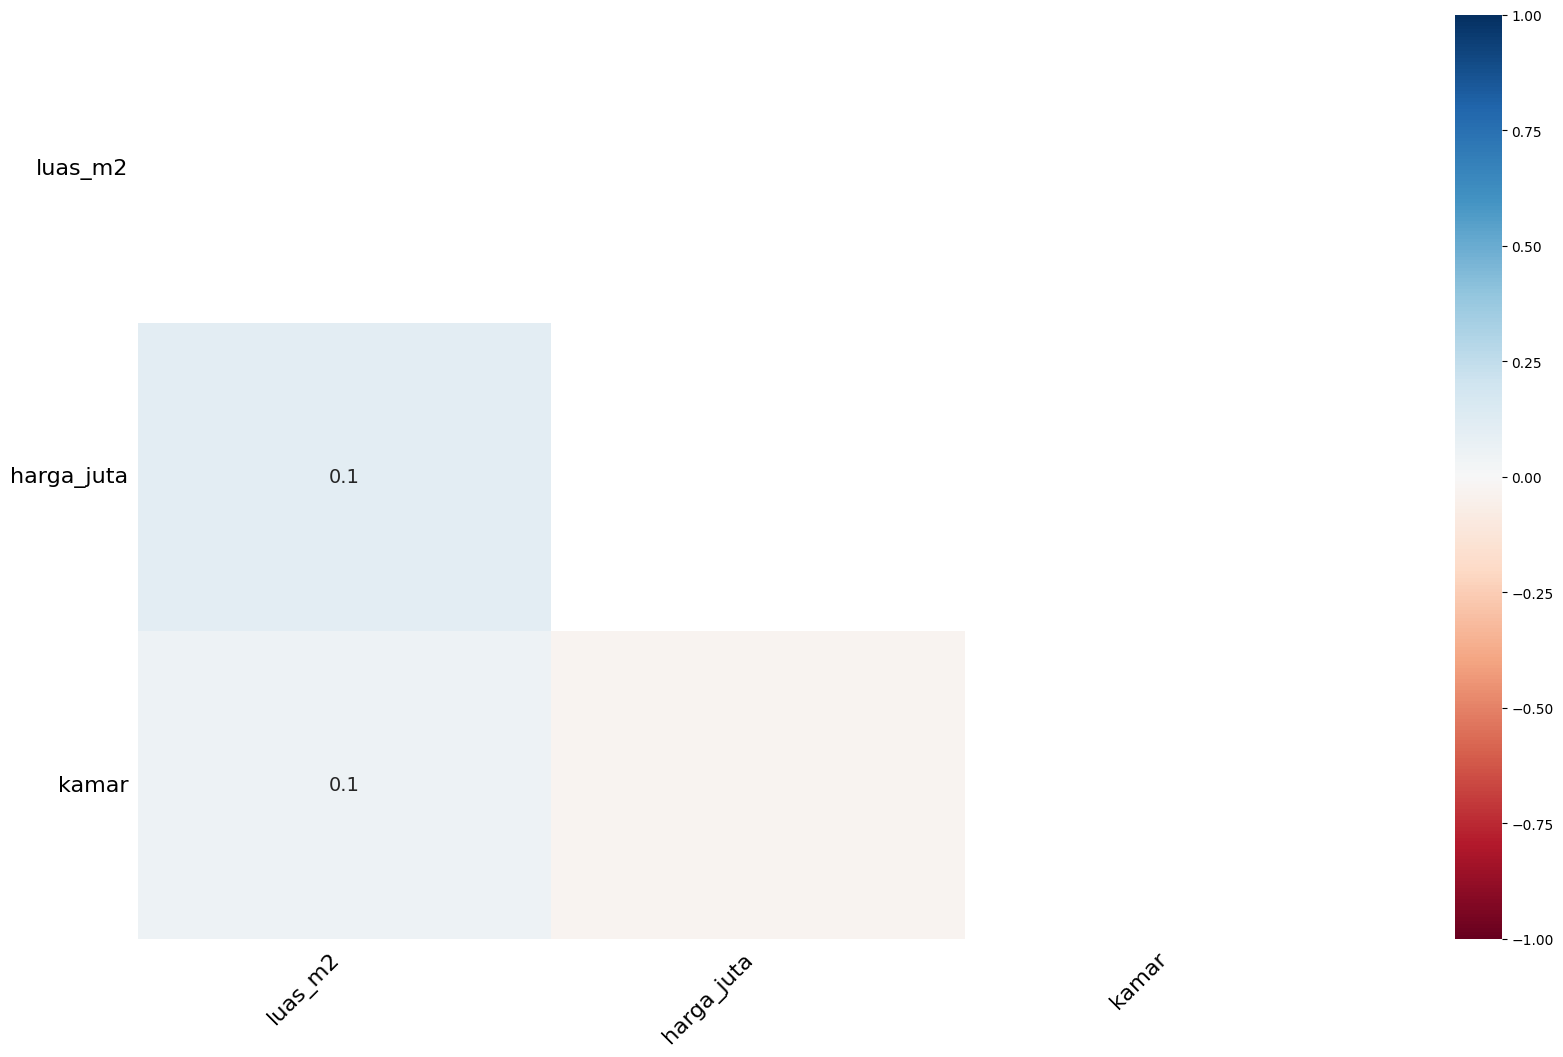

In [ ]:
df = pd.read_csv('drive/MyDrive/Colab Notebooks/kuliah - unsia - data science/pertemuan 3/housing_dirty.csv')

# Jumlah missing per kolom
print(df.isnull().sum())

# Proporsi (%) missing per kolom
pct = (df.isnull().sum() / len(df) * 100).round(2)
print(pct[pct > 0])   # tampilkan yang > 0%

# Identifikasi baris dengan SEMUA nilai missing
all_missing = df[df.isnull().all(axis=1)]

# Identifikasi kolom yang perlu di-drop (> 40% missing)
threshold = 0.4
cols_drop = df.columns[df.isnull().mean() > threshold]
df.drop(columns=cols_drop, inplace=True)

# Visualisasi pola missing (perlu matplotlib)
msno.matrix(df)   # matrix visualisasi
msno.heatmap(df)  # korelasi ketidaklengkapan

In [ ]:
# =============================================
# Eksplorasi Awal
# =============================================
print("\nInfo Dataset:")
print(df.info())

print("\nDeskripsi Statistik:")
print(df.describe())

print("\nMissing Values per Kolom:")
print(df.isnull().sum())


Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            130 non-null    int64  
 1   luas_m2       112 non-null    float64
 2   harga_juta    113 non-null    float64
 3   kota          130 non-null    object 
 4   kamar         120 non-null    float64
 5   tahun_bangun  130 non-null    int64  
 6   kondisi       130 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 7.2+ KB
None

Deskripsi Statistik:
               id      luas_m2    harga_juta       kamar  tahun_bangun
count  130.000000   112.000000  1.130000e+02  120.000000    130.000000
mean    65.500000   267.627679  8.856325e+05    3.433333   2062.638462
std     37.671829   885.664181  9.407144e+06    1.776283    701.684043
min      1.000000   -50.000000 -5.000000e+02    1.000000   1890.000000
25%     33.250000    87.050000  3.450000e+02    2.

In [ ]:
# =============================================
# Hapus Baris Duplikat
# =============================================
n_dup_sebelum = df.duplicated().sum()
print(f"\numlah baris duplikat sebelum dihapus: {n_dup_sebelum}")

df.drop_duplicates(inplace=True)
print(f"Setelah hapus duplikat: {df.shape}")


umlah baris duplikat sebelum dihapus: 0
Setelah hapus duplikat: (130, 7)


In [ ]:
# =============================================
# Normalisasi String
# =============================================
df['kota'] = df['kota'].str.strip().str.title()
df['kondisi'] = df['kondisi'].str.strip().str.lower()
print("tring sudah dinormalisasi")

# Tampilkan contoh kolom kota sebelum & sesudah
print("\nontoh normalisasi kolom 'kota':")
print(df['kota'].unique())

tring sudah dinormalisasi

ontoh normalisasi kolom 'kota':
['Jogja' 'Medan' 'Depok' 'Ygy' 'Jakarta' 'Yogyakarta' 'Bandung' 'Surabaya'
 'Dpk' 'Sby' 'Makassar' 'Mdn' 'Semarang' 'Smg' 'Bdg' 'Mksr']


In [ ]:
# =============================================
# Imputasi Missing Values
# =============================================
# Median untuk numerik (luas_m2, harga_juta)
df['luas_m2'] = df['luas_m2'].fillna(df['luas_m2'].median())
df['harga_juta'] = df['harga_juta'].fillna(df['harga_juta'].median())

# Mode untuk kategorik (kamar)
mode_kota = df['kota'].mode()[0]
df['kamar'] = df['kamar'].fillna(mode_kota)
print("Imputasi missing values selesai (median + mode)")

Imputasi missing values selesai (median + mode)


In [ ]:
# =============================================
# Tangani Outlier dengan IQR Fence
# =============================================
for col in ['harga_juta', 'luas_m2', 'tahun_bangun']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

print(f"Outlier pada kolom '{col}' sudah ditangani dengan IQR Fence")

Outlier pada kolom 'tahun_bangun' sudah ditangani dengan IQR Fence


In [ ]:
# =============================================
# Validasi Akhir
# =============================================
assert df.isnull().sum().sum() == 0, 'Masih ada missing values!'
assert df.duplicated().sum() == 0, 'Masih ada baris duplikat!'

print("\n✅ Validasi Selesai:")
print(f"   - Total missing: {df.isnull().sum().sum()}")
print(f"   - Total duplikat: {df.duplicated().sum()}")
print(f"Shape akhir: {df.shape}")


✅ Validasi Selesai:
   - Total missing: 0
   - Total duplikat: 0
Shape akhir: (130, 7)


In [ ]:
# =============================================
# Ekspor Hasil Bersih
# =============================================
df.to_csv('housing_clean.csv', index=False)
print("✅ Dataset bersih tersimpan ke housing_clean.csv")

✅ Dataset bersih tersimpan ke housing_clean.csv


In [ ]:
url = "https://jsonplaceholder.typicode.com/users"
response = requests.get(url)

if response.status_code == 200:
    data_users = response.json()
    df_api = pd.DataFrame(data_users)
    print(f"\nData dari API berhasil diambil! Shape: {df_api.shape}")
    print(df_api[['id', 'name', 'email']].head())
else:
    print(f"Error akses API: {response.status_code}")


Data dari API berhasil diambil! Shape: (10, 8)
   id              name                      email
0   1     Leanne Graham          Sincere@april.biz
1   2      Ervin Howell          Shanna@melissa.tv
2   3  Clementine Bauch         Nathan@yesenia.net
3   4  Patricia Lebsack  Julianne.OConner@kory.org
4   5  Chelsey Dietrich   Lucio_Hettinger@annie.ca


### Kesimpulan Akhir

Di notebook ini, kita sudah berhasil merapikan data yang awalnya berantakan. Kita mulai dari membereskan data yang kosong, menghapus baris yang ganda, sampai menyeragamkan penulisan nama kota agar rapi. Kita juga sudah membatasi angka-angka yang terlalu ekstrem (outlier) supaya tidak mengacaukan analisis. Terakhir, kita pastikan semuanya bersih dan menyimpannya ke dalam file baru yang siap pakai, serta mencoba mengambil data tambahan dari internet menggunakan API.